In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import soundfile as sf
from tqdm import tqdm
import librosa
import soundfile as sf

In [2]:
def resample(path, new_sr=22050):
    y, sr = librosa.load(path, sr=None)
    y_mono = librosa.to_mono(y)
    y_resampled = librosa.resample(y_mono, orig_sr=sr, target_sr=new_sr)

    return y_resampled

In [3]:
def normalize_signal(path):
    y, sr = librosa.load(path, sr=None)
    max_amplitude = np.max(np.abs(y))
    
    return y / max_amplitude, sr

In [4]:
def segment_signal(y, delta_time=1, sr=22050):
    segment_length = int(delta_time * sr)
    segments = [y[i:i + segment_length] for i in range(0, len(y), segment_length)]
    
    fixed_segments = []
    for segment in segments:
        if len(segment) < segment_length:
            fixed_segments.append(np.pad(segment, (0, segment_length - len(segment)), mode='constant', constant_values=0))
        else:
            fixed_segments.append(segment)


    return fixed_segments

In [5]:
def create_clean_dir(origin_dir, clean_dir, segmented_dir, delta_time = 1, sr=22050):
    origin_dir = Path(origin_dir)
    clean_dir = Path(clean_dir)
    segmented_dir = Path(segmented_dir)
    labels = [f.name for f in origin_dir.iterdir() if f.is_dir()]

    if clean_dir.exists():
        print('Clean directory already exists')
        return
    clean_dir.mkdir(parents=True, exist_ok=True)
    if segmented_dir.exists():
        print('Segmented directory already exists')
        return
    segmented_dir.mkdir(parents=True, exist_ok=True)

    for label in tqdm(labels):
        (clean_dir / label).mkdir(parents=True, exist_ok=True)
        (segmented_dir / label).mkdir(parents=True, exist_ok=True)

        for audio in (origin_dir / label).iterdir():
            if audio.suffix == '.wav':
                y = resample(audio, sr)
                segments = segment_signal(y, delta_time, sr)
                sf.write(clean_dir / label / audio.name, y, sr)

                for i, segment in enumerate(segments):
                    segment_filename = (origin_dir / label / audio.name).stem + f'_{i}.wav'
                    sf.write(segmented_dir / label / segment_filename, segment, sr)

Create clean directories

In [6]:
create_clean_dir('data/IRMAS_data', 'data/IRMAS_clean', 'data/IRMAS_segmented')

Clean directory already exists


Plot mel spectrogram

In [7]:
def plot_melspectrogram(clean_dir, label='cel', name='[cel][cla]0001__1.wav', n_mels=128):
    clean_dir = Path(clean_dir)
    y, sr = librosa.load(clean_dir /label / name, sr=None)
    melspectrogram = librosa.feature.melspectrogram(y=y, 
                                                    sr=sr, 
                                                    n_mels=n_mels, 
                                                    fmax=sr/2)
    melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
    librosa.display.specshow(melspectrogram_db, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

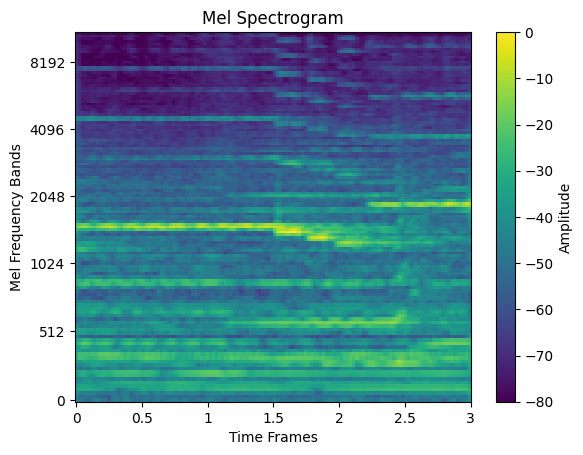

In [8]:
plot_melspectrogram('data/IRMAS_clean')